20:15:28 中国标准时间 WARNING: Structure at 'structures[1]' has bounds that     
                      extend exactly to simulation edges. This can cause        
                      unexpected behavior. If intending to extend the structure 
                      to infinity along one dimension, use td.inf as a size     
                      variable instead to make this explicit.                   

                WARNING: Suppressed 3 WARNING messages.                         

                WARNING: Structure at 'structures[1]' has geometry with zero    
                size along dimensions [2], and with a medium that is not a      
                'Medium2D'. This is probably not correct, since the resulting   
                simulation will depend on the details of the numerical grid.    
                Consider either giving the geometry a nonzero thickness or using
                a 'Medium2D'.                                                   

<Axes: title={'center': 'cross section at z=0.00'}, xlabel='x', ylabel='y'>

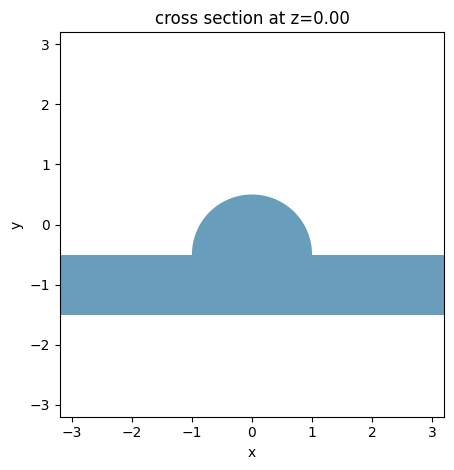

In [2]:
import tidy3d as td
import numpy as np

s = 6 # the size of the computational cell, not including PML
dpml = 0.2# thickness of PML layers

# resolution = 5
# sxy = (s + 2 * dpml) * 0.5  # cell size, including PML
resolution = 50
sxy = (s + 2 * dpml)  # cell size, including PML
cell = (sxy, sxy, 0)
n = 1  # refractive index of material containing the source,没发求得带虚部的介质材料
grid_spec = td.GridSpec.uniform(dl=1/resolution)

star = 0.7
end = 1.2
df1 = 1/star
df2 = 1/end
wvl = (df1 + df2) / 2
fcen =  wvl   
#结构的定义
r=1
n_sphere = 2.0

path_prefix = "D:\\workspace\\mymeep\\cmake-build-debug-visual-studio\\libcore\\"

straight_1 = td.Structure(
    geometry=td.Box(center=(0, -1, 0), size=(sxy, r, 0)),
    medium=td.Medium.from_nk(n_sphere, 0, fcen),
)
circle = td.Structure(
    geometry=td.Sphere(center=(0, r/2 -1, 0), radius=r),
    medium=td.Medium.from_nk(n_sphere, 0, fcen),
)
# box = td.Box(center=(0, -1, 0), size=(sxy, r, 0))
# print(box.inside(0, -1, 1))

sim = td.Simulation(
    size=(sxy, sxy, 0),
    grid_spec=grid_spec,
    structures=[circle, straight_1],
    run_time=1e-12,
    boundary_spec=td.BoundarySpec.all_sides(boundary=td.Periodic()),
)

sim.plot(z=0.0)

In [3]:
import custom.spatial_medium as sm

creator = sm.SpatialMediumCreator4(sim)

medium, cell_permittivity = creator.create()

process total cells: 102400 on 20 cores, iterations: None
grid shape:  [320, 320, 1]
Calc Time elapsed: 1086.8392305999987


4.0


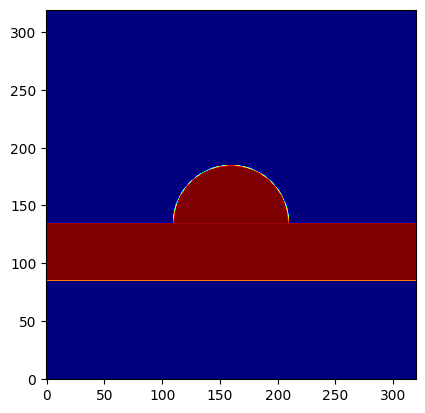

In [13]:
# vis
import matplotlib.pyplot as plt
cp = np.ascontiguousarray(cell_permittivity)
d = cp.squeeze()
plt.imshow(d.T, origin='lower', cmap='jet')
# plt.imshow(d)
print(d[50, 100])

In [12]:
# save as npy
np.save(path_prefix +"2d_sphere_medium-4.npy", cp)

In [1]:
creator = sm.SpatialMediumCreator5(sim)

_, cell_permittivity = creator.create()

NameError: name 'sm' is not defined

In [ ]:
plt.imshow(cell_permittivity)
np.save(path_prefix +"2d_sphere_medium-5.npy", cell_permittivity)

NameError: name 'plt' is not defined